In [32]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras import layers
import pickle
from sklearn.preprocessing import LabelEncoder

In [33]:
with open('../datasets/gtzan_mfccs.pkl', 'rb') as f:
    gtzan_mfccs = pickle.load(f)

In [34]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Create indices and shuffle
indices = np.arange(len(gtzan_mfccs[0]))
np.random.shuffle(indices)

# 2. Shuffle features and labels using the same indices
shuffled_features = gtzan_mfccs[0][indices]
shuffled_labels = gtzan_mfccs[1][indices]

le = LabelEncoder()
encoded_labels = le.fit_transform(shuffled_labels)

# 3. Split into train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    shuffled_features,
    encoded_labels,
    test_size=0.2,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

# 4. Create TensorFlow Dataset objects
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))

# 5. Shuffle batches for training
buffer_size = len(X_train)  # Full dataset shuffling
batch_size = 32

train_dataset = train_dataset.shuffle(buffer_size).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [35]:
def create_mfcc_cnn(input_shape):
    inputs = keras.Input(shape=input_shape)
    
    if len(input_shape) == 2:
        x = layers.Reshape((*input_shape, 1))(inputs)
    else:
        x = inputs

    # Layer 1: 128 filters
    x = layers.Conv2D(128, (3, 3), strides=(1, 1), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.5)(x)
    
    # Layer 2: 64 filters
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.5)(x)
    
    # Layer 3: 32 filters
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.5)(x)
    
    # Layer 4: 16 filters
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Dropout(0.5)(x)
    
    # Layer 5: 8 filters
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Dropout(0.5)(x)
    
    # Flatten before FC layer
    x = layers.Flatten()(x)
    outputs = layers.Dense(len(le.classes_), activation='softmax')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    
    return model

In [36]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for features, labels in dataset:
        reshaped_features = tf.reshape(features, (*features.shape, 1))
        all_features.append(reshaped_features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

In [37]:
train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(val_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

In [38]:
input_shape = train_features[0].shape
genre_model = create_mfcc_cnn(input_shape)
genre_model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 2578, 20, 1)]     0         
                                                                 
 conv2d_10 (Conv2D)          (None, 2578, 20, 128)     1280      
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 1289, 10, 128)     0         
 ng2D)                                                           
                                                                 
 dropout_10 (Dropout)        (None, 1289, 10, 128)     0         
                                                                 
 conv2d_11 (Conv2D)          (None, 1289, 10, 64)      73792     
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 644, 5, 64)        0         
 ng2D)                                                     

In [39]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
      filepath="feature_extraction.keras",
      save_best_only=True,
      monitor="val_loss")
]

history = genre_model.fit(
    train_features, train_labels,
    epochs=300,
    validation_data=(val_features, val_labels),
    callbacks=callbacks)

Epoch 1/300
19/19 [==============================] - 2s 101ms/step - loss: 17.4377 - accuracy: 0.0818 - val_loss: 2.3065 - val_accuracy: 0.0950
Epoch 2/300
19/19 [==============================] - 2s 85ms/step - loss: 2.7485 - accuracy: 0.1152 - val_loss: 2.3037 - val_accuracy: 0.1050
Epoch 3/300
19/19 [==============================] - 2s 84ms/step - loss: 2.3895 - accuracy: 0.0968 - val_loss: 2.3043 - val_accuracy: 0.0750
Epoch 4/300
19/19 [==============================] - 2s 87ms/step - loss: 2.3250 - accuracy: 0.1068 - val_loss: 2.3047 - val_accuracy: 0.0750
Epoch 5/300
19/19 [==============================] - 2s 85ms/step - loss: 2.2927 - accuracy: 0.1135 - val_loss: 2.3052 - val_accuracy: 0.0750
Epoch 6/300
19/19 [==============================] - 2s 84ms/step - loss: 2.2817 - accuracy: 0.1285 - val_loss: 2.3057 - val_accuracy: 0.0750
Epoch 7/300
19/19 [==============================] - 2s 88ms/step - loss: 2.2693 - accuracy: 0.1285 - val_loss: 2.3063 - val_accuracy: 0.0650
Epoc

In [40]:
transf_model = keras.models.load_model("feature_extraction.keras")

# Evaluate model
loss, accuracy = transf_model.evaluate(test_features, test_labels)
print('Loss: %.4f, Accuracy: %.2f%%' % (loss, accuracy*100))

7/7 [==============================] - 0s 20ms/step - loss: 1.8905 - accuracy: 0.3150
Loss: 1.8905, Accuracy: 31.50%


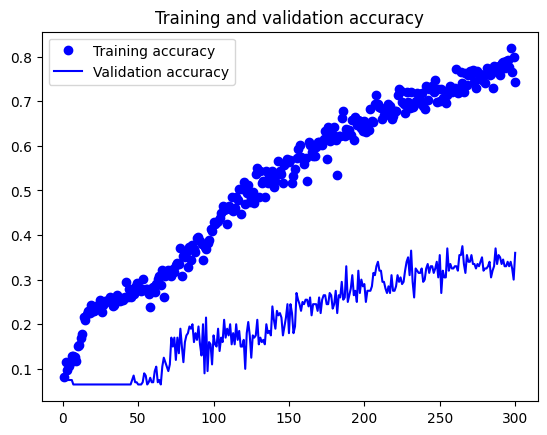

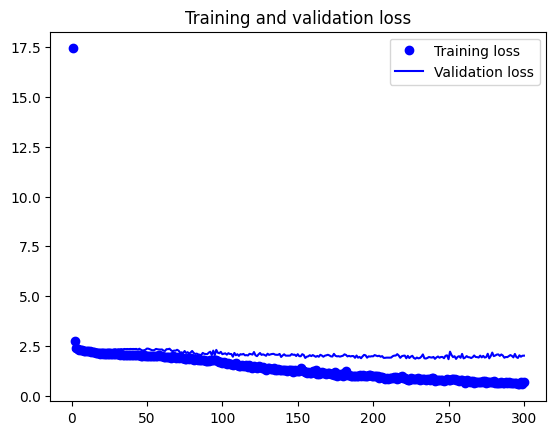

In [41]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Get number of epochs for x-axis
epochs = range(1, len(accuracy) + 1)

# Plot
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

7/7 [==============================] - 0s 17ms/step


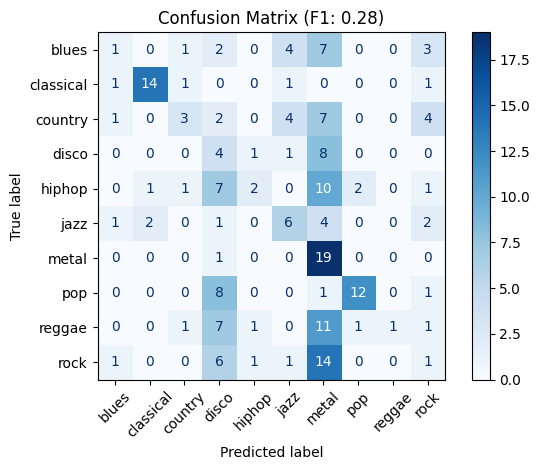

Loss: 1.8905, Accuracy: 31.50%
Weighted F1 Score: 0.28


In [42]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Load model and get predictions
transf_model = keras.models.load_model("feature_extraction.keras")

# Generate class predictions (instead of probabilities)
y_pred = transf_model.predict(test_features)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class indices

# Ensure labels are integers if using sparse categorical crossentropy
y_true = test_labels  # Should already be integers from LabelEncoder

# Calculate metrics
f1 = f1_score(y_true, y_pred_classes, average='weighted')
cm = confusion_matrix(y_true, y_pred_classes)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (F1: {f1:.2f})')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()


# Print evaluation metrics
loss, accuracy = transf_model.evaluate(test_features, test_labels, verbose=0)
print(f'Loss: {loss:.4f}, Accuracy: {accuracy*100:.2f}%')
print(f'Weighted F1 Score: {f1:.2f}')

In [43]:
from tensorflow.keras.losses import sparse_categorical_crossentropy

@keras.saving.register_keras_serializable(package="Custom")
class HyperbolicGenreLoss(tf.keras.losses.Loss):
    def __init__(self, class_points, genre_labels,
                 reduction=tf.keras.losses.Reduction.AUTO,
                 name="hyperbolic_genre_loss"):
        super().__init__(name=name)
        with tf.device('/CPU:0'):
            self.class_points = tf.Variable(
                class_points, 
                dtype=tf.float32,
                trainable=False
            )
        self.genre_labels = genre_labels
        self.genre_to_idx = {g:i for i,g in enumerate(genre_labels)}

    def get_config(self):
        config = super().get_config()
        config.update({
            "class_points": self.class_points.numpy().tolist(),
            "genre_labels": self.genre_labels
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        # Convert numpy array back to TF variable
        config["class_points"] = tf.Variable(
            config["class_points"], 
            trainable=False
        )
        return cls(**config)
        
    def hyperbolic_distance(self, z1, z2):
        """Poincaré distance metric between Euclidean coordinates z1 and z2"""
        with tf.device('/CPU:0'):
            z1 = tf.cast(z1, tf.float32)
            z2 = tf.cast(z2, tf.float32)
            eps = 1e-5
            
            z1_norm = tf.reduce_sum(z1**2, axis=-1)
            z2_norm = tf.reduce_sum(z2**2, axis=-1)
            
            numerator = 2 * tf.reduce_sum((z1 - z2)**2, axis=-1)
            denominator = (1 - z1_norm) * (1 - z2_norm) + eps
            
            return tf.math.acosh(1.0 + numerator / denominator)

    def call(self, y_true, y_pred):
        # Ensure tensors flow between devices correctly
        with tf.device('/CPU:0'):
            y_true = tf.cast(y_true, tf.int32)
            z_true = tf.gather(self.class_points, y_true)
            
            # Calculate distances on CPU
            z_true_exp = tf.expand_dims(z_true, 1)
            all_points_exp = tf.expand_dims(self.class_points, 0)
            distances = self.hyperbolic_distance(z_true_exp, all_points_exp)
            
        # Copy distances to GPU for mixing with other tensors
        distances = tf.identity(distances)
        
        # GPU-based operations
        with tf.device('/GPU:0'):
            weights = tf.nn.softmax(y_pred, axis=-1)
            weighted_dist = tf.reduce_sum(weights * distances, axis=-1)
            sce = sparse_categorical_crossentropy(y_true, y_pred)
            
        return sce * weighted_dist



In [44]:
class_points, genres = pickle.load(open('../embeddings/point_genre_map.pkl', 'rb'))

genres[genres.index('hip hop')] = 'hiphop'
print(genres)

# Initialize with your genre order
genre_loss = HyperbolicGenreLoss(
    class_points=class_points,
    genre_labels=genres  # Must match LabelEncoder order!
)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [45]:
with keras.saving.custom_object_scope({'HyperbolicGenreLoss': HyperbolicGenreLoss}):
    poincare_model = create_mfcc_cnn(input_shape)
    poincare_model.summary()

    poincare_model.compile(
        optimizer='adam',
        loss=genre_loss,
        metrics=['accuracy']
    )

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 2578, 20, 1)]     0         
                                                                 
 conv2d_15 (Conv2D)          (None, 2578, 20, 128)     1280      
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 1289, 10, 128)     0         
 ng2D)                                                           
                                                                 
 dropout_15 (Dropout)        (None, 1289, 10, 128)     0         
                                                                 
 conv2d_16 (Conv2D)          (None, 1289, 10, 64)      73792     
                                                                 
 max_pooling2d_16 (MaxPooli  (None, 644, 5, 64)        0         
 ng2D)                                                     

In [46]:
with keras.saving.custom_object_scope({'HyperbolicGenreLoss': HyperbolicGenreLoss}):
  callbacks = [
      keras.callbacks.ModelCheckpoint(
        filepath="poincare_feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss")
  ]

  poincare_history = poincare_model.fit(
      train_features, train_labels,
      epochs=500,
      validation_data=(val_features, val_labels),
      callbacks=callbacks)

Epoch 1/500
19/19 [==============================] - 3s 123ms/step - loss: 91.2176 - accuracy: 0.0985 - val_loss: 13.7605 - val_accuracy: 0.1050
Epoch 2/500
19/19 [==============================] - 2s 104ms/step - loss: 17.8787 - accuracy: 0.0985 - val_loss: 13.7315 - val_accuracy: 0.1000
Epoch 3/500
19/19 [==============================] - 2s 102ms/step - loss: 14.3885 - accuracy: 0.0985 - val_loss: 13.7364 - val_accuracy: 0.0800
Epoch 4/500
19/19 [==============================] - 2s 101ms/step - loss: 13.9861 - accuracy: 0.0935 - val_loss: 13.7394 - val_accuracy: 0.0750
Epoch 5/500
19/19 [==============================] - 2s 101ms/step - loss: 13.8529 - accuracy: 0.1185 - val_loss: 13.7416 - val_accuracy: 0.0750
Epoch 6/500
19/19 [==============================] - 2s 106ms/step - loss: 13.9158 - accuracy: 0.1035 - val_loss: 13.7448 - val_accuracy: 0.0750
Epoch 7/500
19/19 [==============================] - 2s 103ms/step - loss: 13.6309 - accuracy: 0.1219 - val_loss: 13.7483 - val_ac

In [47]:
poincare_transf_model = keras.models.load_model("poincare_feature_extraction.keras")

# Evaluate model
loss, accuracy = poincare_transf_model.evaluate(test_features, test_labels)
print('Loss: %.4f, Accuracy: %.2f%%' % (loss, accuracy*100))

7/7 [==============================] - 0s 22ms/step - loss: 12.2599 - accuracy: 0.3850
Loss: 12.2599, Accuracy: 38.50%


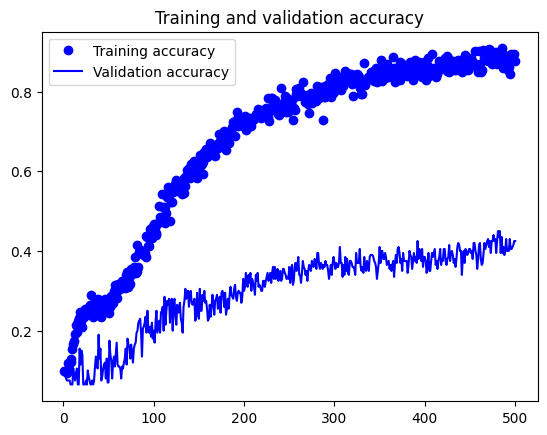

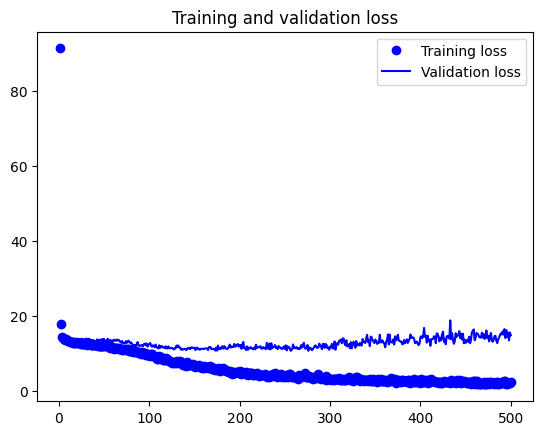

In [50]:
accuracy = poincare_history.history["accuracy"]
val_accuracy = poincare_history.history["val_accuracy"]
loss = poincare_history.history["loss"]
val_loss = poincare_history.history["val_loss"]

# Get number of epochs for x-axis
epochs = range(1, len(accuracy) + 1)

# Plot
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

7/7 [==============================] - 0s 17ms/step


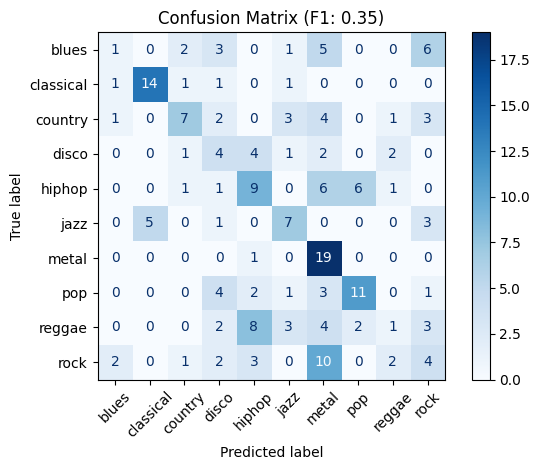

Loss: 12.2599, Accuracy: 38.50%
Weighted F1 Score: 0.35


In [51]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

y_pred = poincare_transf_model.predict(test_features)
y_pred_classes = np.argmax(y_pred, axis=1)  

y_true = test_labels  

# Calculate metrics
f1 = f1_score(y_true, y_pred_classes, average='weighted')
cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (F1: {f1:.2f})')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('poincare_confusion_matrix.png')
plt.show()


# Print evaluation metrics
loss, accuracy = poincare_transf_model.evaluate(test_features, test_labels, verbose=0)
print(f'Loss: {loss:.4f}, Accuracy: {accuracy*100:.2f}%')
print(f'Weighted F1 Score: {f1:.2f}')